### Scroll down to see the inference engine where API is exposed.

1. ngRok is used to connect from collab to local server. ngRok access token needs to be added.
2. Image upload facility is provided.

### Get access to MedGemma

Before you get started, make sure that you have access to MedGemma models on Hugging Face:

1. If you don't already have a Hugging Face account, you can create one for free by clicking [here](https://huggingface.co/join).
2. Head over to the [MedGemma model page](https://huggingface.co/google/medgemma-1.5-4b-it) and accept the usage conditions.

### Authenticate with Hugging Face

Generate a Hugging Face `read` access token by going to [settings](https://huggingface.co/settings/tokens).

If you are using Google Colab, add your access token to the Colab Secrets manager to securely store it. If not, proceed to run the cell below to authenticate with Hugging Face.

1. Open your Google Colab notebook and click on the 🔑 Secrets tab in the left panel. <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="The Secrets tab is found on the left panel." width=50%>
2. Create a new secret with the name `HF_TOKEN`.
3. Copy/paste your token key into the Value input box of `HF_TOKEN`.
4. Toggle the button on the left to allow notebook access to the secret.

In [1]:
import os
import sys

google_colab = "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT")

if google_colab:
    # Use secret if running in Google Colab
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

### Install dependencies

In [2]:
! pip install --upgrade --quiet accelerate bitsandbytes transformers flask pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 12.4 MB/s eta 0:00:00


## Load model from Hugging Face Hub

In [2]:
from transformers import BitsAndBytesConfig
import torch

model_variant = "medgemma-1.5-4b-it"  # @param ["medgemma-1.5-4b-it", "medgemma-4b-it", "medgemma-27b-it", "medgemma-27b-text-it"]
model_id = f"google/{model_variant}"

# @markdown ---
# @markdown To reduce memory usage, [quantize](https://huggingface.co/docs/transformers/en/quantization/bitsandbytes) the model in 4-bit. **Note:** 4-bit quantization is required to run MedGemma 27B on an A100 GPU in Google Colab. The performance of quantized versions has not been evaluated.
use_quantization = True  # @param {type: "boolean"}

# @markdown ---
# @markdown MedGemma 1.5 4B and MedGemma 27B variants support thinking. If enabled, a system instruction will be added to prompt the model to output its reasoning between two special tokens `<unused94>` and `<unused95>` followed by the final response. **Note:** This notebook shows how to enable thinking for any multimodal or text-only task but it may not benefit some use cases. Thinking may potentially improve results on challenging text-only tasks at the cost of generating more tokens. Thoroughly validate the model's performance and assess the inference time and cost when enabling thinking.
is_thinking = False  # @param {type: "boolean"}
THINKING_VARIANTS = [
    "medgemma-1.5-4b-it",
    "medgemma-27b-it",
    "medgemma-27b-text-it",
]
if is_thinking and model_variant not in THINKING_VARIANTS:
    is_thinking = False
    print(
        "Note: Thinking is enabled for a non-thinking variant. Setting "
        "`is_thinking` to `False`."
    )

# If running a 27B variant in Google Colab, check if the runtime satisfies
# memory requirements
if "27b" in model_variant and google_colab:
    if not ("A100" in torch.cuda.get_device_name(0) and use_quantization):
        raise ValueError(
            "Runtime has insufficient memory to run a 27B variant. "
            "Please select an A100 GPU and use 4-bit quantization."
        )

model_kwargs = dict(
    dtype=torch.bfloat16,
    device_map="auto",
)

if use_quantization:
    model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)

The following sections contain standalone examples demonstrating how to use the model both directly and with the [`pipeline`](https://huggingface.co/docs/transformers/en/main_classes/pipelines) API. The `pipeline` API provides a simple way to use the model for inference while abstracting away complex details,  while directly using the model gives you complete control over the inference process, including preprocessing and postprocessing. In practice, you should select the method that is best suited for your use case.

Here, you will load the model directly and with the `pipeline` API for use in the next sections. Note that the multimodal variants and the 27B text-only variant are loaded with their respective tasks and classes.

**Load model with the `pipeline` API**

In [3]:
from transformers import pipeline

if "text" in model_variant:
    pipe = pipeline("text-generation", model=model_id, model_kwargs=model_kwargs)
else:
    pipe = pipeline("image-text-to-text", model=model_id, model_kwargs=model_kwargs)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


**Load model directly**

In [4]:
if "text" in model_variant:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
else:
    from transformers import AutoModelForImageTextToText, AutoProcessor
    model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
    processor = AutoProcessor.from_pretrained(model_id)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

## Run inference on images and text

This section demonstrates running inference on image-based tasks using multimodal variants.

**Note:** Proceed to [Run inference on text only](#scrollTo=tcyXG4lTpY4X) if you have selected the 27B text-only variant.

In [5]:
if "text" in model_variant:
    raise ValueError(
        "You are using a text-only variant which does not support multimodal "
        "inputs. Please proceed to the 'Run inference on text only' section."
    )

**Specify image and text inputs**

In [6]:
import os
from PIL import Image
from IPython.display import Image as IPImage, display, Markdown

prompt = "65-year-old male presenting with acute shortness of breath and swollen ankles for 48 hours. History of Hypertension. Vitals: BP 155/90, HR 92. Meds: Lisinopril 20mg daily. Generatethe council report"  # @param {type: "string"}

# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
image_url = "https://medlineplus.gov/images/Xray.jpg"  # @param {type: "string"}
! wget -nc -q {image_url}
image_filename = os.path.basename(image_url)
image = Image.open(image_filename)

**Format conversation**

In [7]:
# role_instruction = "You are an expert radiologist."

role_instruction = """You are the M.A.C.C. Medical Council.
Analyze the user's patient case and image. Output a multi-agent consultation.

EXAMPLE OUTPUT FORMAT:
[RADIOLOGIST_START]
Findings: The cardiac silhouette is enlarged. There is prominent vascular congestion in the upper lobes. No focal consolidation.
[RADIOLOGIST_END]

[CARDIOLOGIST_START]
Diagnosis: Acute Decompensated Heart Failure (ADHF).
Plan: Initiate IV Furosemide 40mg immediately. Monitor urine output.
[CARDIOLOGIST_END]

[PHARMACIST_START]
Safety Audit: Patient is on Lisinopril. Adding Furosemide is appropriate but requires monitoring of serum potassium and renal function to prevent acute kidney injury.
[PHARMACIST_END]

[CONSENSUS_START]
1. Administer diuretics. 2. Order Echocardiogram. 3. Daily weights and fluid restriction.
[CONSENSUS_END]

Now, provide the report for the current patient:"""

if is_thinking:
    system_instruction = f"SYSTEM INSTRUCTION: think silently if needed. {role_instruction}"
    max_new_tokens = 1300
else:
    system_instruction = role_instruction
    max_new_tokens = 300

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": system_instruction}]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {"type": "image", "image": image}
        ]
    }
]

**Run model with the `pipeline` API**

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

65-year-old male presenting with acute shortness of breath and swollen ankles for 48 hours. History of Hypertension. Vitals: BP 155/90, HR 92. Meds: Lisinopril 20mg daily. Generatethe council report

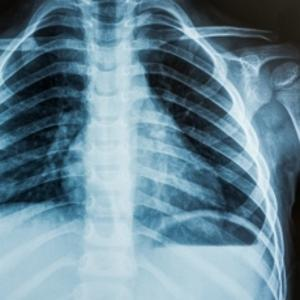

---

**[ MedGemma ]**

[RADIOLOGIST_START]
Findings: The heart size appears enlarged. There is evidence of pulmonary edema, characterized by increased interstitial markings and perihilar haze, particularly in the lower lung zones. The costophrenic angles are blunted, suggesting possible pleural effusions. The mediastinum is midline. No pneumothorax is evident. The bony structures are intact.
[RADIOLOGIST_END]

[CARDIOLOGIST_START]
Diagnosis: Based on the clinical presentation (acute shortness of breath, ankle swelling) and radiographic findings (cardiomegaly, pulmonary edema, possible pleural effusions), the most likely diagnosis is Acute Decompensated Heart Failure (ADHF). The patient's history of hypertension is a significant risk factor.
Plan: Initiate intravenous diuretics (e.g., Furosemide) to manage fluid overload. Consider oxygen therapy. Monitor vital signs closely.
[CARDIOLOGIST_END]

[PHARMACIST_START]
Safety Audit: Patient is on Lisinopril. Adding Furosemide is appropriate for managing fluid overload in ADHF. However, monitor serum potassium and renal function closely due to the diuretic effect. Ensure adequate hydration unless contraindicated.
[PHARMACIST_END]

[CONSENSUS_START]
1. Administer IV Furosemide. 2. Order Echocardiogram. 3. Monitor vital signs and fluid balance. 4. Consider oxygen

---

In [8]:
output = pipe(text=messages, max_new_tokens=max_new_tokens, do_sample=False)
response = output[0]["generated_text"][-1]["content"]

display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}"))
display(IPImage(filename=image_filename, height=300))
if is_thinking:
    thought, response = response.split("<unused95>")
    thought = thought.replace("<unused94>thought\n", "")
    display(Markdown(f"---\n\n**[ MedGemma thinking trace ]**\n\n{thought}"))
display(Markdown(f"---\n\n**[ MedGemma ]**\n\n{response}\n\n---"))

**Run the model directly**

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


---

**[ User ]**

65-year-old male presenting with acute shortness of breath and swollen ankles for 48 hours. History of Hypertension. Vitals: BP 155/90, HR 92. Meds: Lisinopril 20mg daily. Generatethe council report

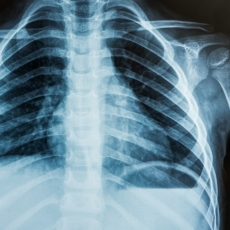

---

**[ MedGemma ]**

[RADIOLOGIST_START]
Findings: The heart size appears enlarged. There is evidence of pulmonary edema, characterized by increased interstitial markings and perihilar haze, particularly in the lower lung zones. The costophrenic angles are blunted, suggesting possible pleural effusions. The mediastinum is midline. No pneumothorax is evident. The bony structures are intact.
[RADIOLOGIST_END]

[CARDIOLOGIST_START]
Diagnosis: Based on the clinical presentation (acute shortness of breath, ankle swelling) and radiographic findings (cardiomegaly, pulmonary edema, possible pleural effusions), the most likely diagnosis is Acute Decompensated Heart Failure (ADHF). The patient's history of hypertension is a significant risk factor.
Plan: Initiate intravenous diuretics (e.g., Furosemide) to manage fluid overload. Consider oxygen therapy. Monitor vital signs closely.
[CARDIOLOGIST_END]

[PHARMACIST_START]
Safety Audit: Patient is on Lisinopril. Adding Furosemide is appropriate for managing fluid overload in ADHF. However, monitor serum potassium and renal function closely due to the diuretic effect. Ensure adequate hydration unless contraindicated.
[PHARMACIST_END]

[CONSENSUS_START]
1. Administer IV Furosemide. 2. Order Echocardiogram. 3. Monitor vital signs and fluid balance. 4. Consider oxygen

---

In [9]:
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generation = generation[0][input_len:]

response = processor.decode(generation, skip_special_tokens=True)

display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}"))
display(IPImage(filename=image_filename, height=300))
if is_thinking:
    thought, response = response.split("<unused95>")
    thought = thought.replace("<unused94>thought\n", "")
    display(Markdown(f"---\n\n**[ MedGemma thinking trace ]**\n\n{thought}"))
display(Markdown(f"---\n\n**[ MedGemma ]**\n\n{response}\n\n---"))

## Run inference on text only

This section demonstrates running inference on text-based tasks.

**Specify text prompt and format conversation**

In [19]:
from IPython.display import Markdown

prompt = "How do you differentiate bacterial from viral pneumonia?"  # @param {type: "string"}

role_instruction = "You are a helpful medical assistant."
if is_thinking:
    system_instruction = f"SYSTEM INSTRUCTION: think silently if needed. {role_instruction}"
    max_new_tokens = 1500
else:
    system_instruction = role_instruction
    max_new_tokens = 500

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": system_instruction}]
    },
    {
        "role": "user",
        "content": [{"type": "text", "text": prompt}]
    }
]

**Run model with the `pipeline` API**

In [20]:
output = pipe(messages, max_new_tokens=max_new_tokens, do_sample=False)
response = output[0]["generated_text"][-1]["content"]

display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}\n\n---"))
if is_thinking:
    thought, response = response.split("<unused95>")
    thought = thought.replace("<unused94>thought\n", "")
    display(Markdown(f"**[ MedGemma thinking trace ]**\n\n{thought}\n\n---"))
display(Markdown(f"**[ MedGemma ]**\n\n{response}\n\n---"))

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

How do you differentiate bacterial from viral pneumonia?

---

**[ MedGemma ]**

As a helpful medical assistant, I can provide information on how to differentiate between bacterial and viral pneumonia, but it's crucial to understand that **I cannot provide medical diagnoses.** This information is for educational purposes only and should not replace professional medical advice from a qualified healthcare provider.

Here's a general overview of how doctors differentiate between bacterial and viral pneumonia, keeping in mind that these are often overlapping conditions and a definitive diagnosis usually requires specific tests:

**Key Differences and Diagnostic Approaches:**

1.  **Clinical Presentation (Symptoms):**
    *   **Both:** Can present with fever, cough (often productive with thick sputum), shortness of breath, chest pain, fatigue, chills, and sometimes confusion (especially in the elderly).
    *   **Bacterial:** Often associated with a more abrupt onset and severe symptoms. Sputum is typically purulent (thick, yellow/green).
    *   **Viral:** Onset can be more gradual. Sputum may be less thick or even dry.

2.  **Risk Factors:**
    *   **Bacterial:** Often associated with preceding upper respiratory infections (like the flu, common cold), exposure to certain bacteria (like *Streptococcus pneumoniae*, *Haemophilus influenzae*, *Mycoplasma pneumoniae*, *Legionella pneumophila*), underlying lung conditions (like COPD, cystic fibrosis), immunosuppression, or recent hospitalization.
    *   **Viral:** Often associated with influenza, RSV, COVID-19, adenovirus, metapneumovirus, etc. Can occur in anyone, but certain groups (young children, elderly, immunocompromised) are at higher risk.

3.  **Physical Examination Findings:**
    *   **Both:** May show signs of respiratory distress (tachypnea, tachycardia, hypoxia), crackles or rales on auscultation (listening to the lungs), and potentially signs of consolidation (like dullness to percussion or increased tactile fremitus).
    *   **Bacterial:** May show signs of consolidation (e.g., lobar pneumonia).
    *   **Viral:** May show diffuse interstitial patterns (e.g., atypical pneumonia).

4.  **Diagnostic Tests:**
    *   **Chest X-ray:**
        *   **Bacterial:** Often shows lobar consolidation (a dense area of opacity in one or more lobes), but can also be patchy or diffuse.
        *   **Viral:**

---

**Run the model directly**

In [ ]:
processor_or_tokenizer = tokenizer if "text" in model_variant else processor

inputs = processor_or_tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generation = generation[0][input_len:]

response = processor_or_tokenizer.decode(generation, skip_special_tokens=True)

display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}\n\n---"))
if is_thinking:
    thought, response = response.split("<unused95>")
    thought = thought.replace("<unused94>thought\n", "")
    display(Markdown(f"**[ MedGemma thinking trace ]**\n\n{thought}\n\n---"))
display(Markdown(f"**[ MedGemma ]**\n\n{response}\n\n---"))

---

**[ User ]**

How do you differentiate bacterial from viral pneumonia?

---

**[ MedGemma ]**

Okay, let's break down how healthcare professionals differentiate between bacterial and viral pneumonia. It's important to remember that I'm an AI and cannot provide medical advice. This information is for educational purposes only. A definitive diagnosis always requires a healthcare professional.

Differentiating bacterial and viral pneumonia can be tricky because symptoms often overlap. However, there are key differences in presentation, history, and diagnostic tests that help clinicians distinguish between them.

Here's a breakdown of the key differentiating factors:

**1. Clinical Presentation & History:**

*   **Onset:**
    *   **Bacterial:** Often sudden and abrupt onset. Patients may feel fine one day and severely ill the next.
    *   **Viral:** Typically more gradual onset, often starting with cold-like symptoms (runny nose, cough, sore throat) that then progress to pneumonia symptoms.
*   **Symptoms:**
    *   **Bacterial:** High fever (often >102°F / 39°C), shaking chills, productive cough (producing thick, often colored sputum - yellow, green, rust-colored), shortness of breath, chest pain (often sharp, pleuritic - worse with breathing).
    *   **Viral:** Lower-grade fever (though can be high), dry cough (less likely to produce thick sputum), muscle aches (myalgia), headache, fatigue, sore throat. Shortness of breath can occur but might be less severe initially than in bacterial pneumonia.
*   **Patient History:**
    *   **Bacterial:** Less likely to have preceding upper respiratory infection (URI) symptoms. May have underlying conditions like COPD, heart failure, diabetes, or be immunocompromised.
    *   **Viral:** Often preceded by URI symptoms. More common in younger children and older adults. Can occur in outbreaks (e.g., influenza season).

**2. Physical Examination:**

*   **Lung Sounds:**
    *   **Bacterial:** Often localized findings. Crackles (rales), rhonchi, or decreased breath sounds over the affected area.
    *   **Viral:** Lung sounds might be more diffuse (spread throughout) or relatively normal, especially early on. Wheezing can sometimes be present.
*   **General Appearance:**
    *   **Bacterial:** Patients often appear more acutely ill, toxic-looking.
    *   **Viral:** Patients might appear less acutely ill initially,

---

### Create inference server which will expose the model API

In [12]:
!pip install flask-cors pyngrok --quiet

In [11]:
# Run this once to authenticate your session
!ngrok authtoken <token>

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [14]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import torch

app = Flask(__name__)
CORS(app)

@app.route("/inference", methods=["POST"])
def inference():
    data = request.json
    user_prompt = data.get("prompt", "")
    agent_role = data.get("agent_role", "Radiologist")

    # System Instruction varies based on the "Hat" the model is wearing
    messages = [
        {"role": "system", "content": [{"type": "text", "text": f"You are an expert {agent_role}."}]},
        {"role": "user", "content": [{"type": "text", "text": user_prompt}, {"type": "image", "image": image}]}
    ]

    # Model Execution
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
        response = processor.decode(generation[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

    return jsonify({"response": response})

# START TUNNEL (Replace with your token: dashboard.ngrok.com)
# !ngrok authtoken YOUR_NGROK_TOKEN
public_url = ngrok.connect(5000).public_url
print(f"\n COPY THIS URL FOR LOCAL BACKEND:\n{public_url}\n")
app.run(port=5000)


 COPY THIS URL FOR LOCAL BACKEND:
https://stereotyped-unbedizened-theodore.ngrok-free.dev

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:14:54] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:17:49] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:21:31] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:24:34] "POST /inference HTTP/1.1" 200 -


Image upload facility along with inference

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import torch
import base64
from PIL import Image
from io import BytesIO

app = Flask(__name__)
CORS(app)

@app.route("/inference", methods=["POST"])
def inference():
    data = request.json
    user_prompt = data.get("prompt", "")
    agent_role = data.get("agent_role", "Radiologist")
    image_b64 = data.get("image") # New: Local image data

    # Convert B64 to PIL Image
    raw_image = Image.open(BytesIO(base64.b64decode(image_b64.split(',')[1]))).convert("RGB")

    messages = [
        {"role": "system", "content": [{"type": "text", "text": f"You are an expert {agent_role}. Focus on clinical accuracy."}]},
        {"role": "user", "content": [{"type": "text", "text": user_prompt}, {"type": "image", "image": raw_image}]}
    ]

    inputs = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        # Fixed: Increased to 1200 to prevent Pharmacist truncation
        generation = model.generate(**inputs, max_new_tokens=1500, do_sample=False)
        response = processor.decode(generation[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

    return jsonify({"response": response})

public_url = ngrok.connect(5000).public_url
print(f"URL: {public_url}")
app.run(port=5000)

URL: https://stereotyped-unbedizened-theodore.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:49:01] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:52:05] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 21:56:26] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 22:06:47] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
INFO:werkzeug:127.0.0.1 - - [24/Feb/2026 22:09:32] "POST /inference HTTP/1.1" 200 -
Setting `pad_token_id` to `eos_token